<a href="https://colab.research.google.com/github/alearecuest/anyoneai-exercises-sprint_1/blob/main/4_1_1_THEORY_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation

In [2]:

!gdown "1NLxxzZR-UCsvpCNZZ5dU19qLcGCW1axE"

income_df = pd.read_csv("Inc_Exp_Data.csv")
income_df.head()

Downloading...
From: https://drive.google.com/uc?id=1NLxxzZR-UCsvpCNZZ5dU19qLcGCW1axE
To: /content/Inc_Exp_Data.csv
100% 2.08k/2.08k [00:00<00:00, 7.99MB/s]


,Mthly_HH_Income,Mthly_HH_Expense,No_of_Fly_Members,Emi_or_Rent_Amt,Annual_HH_Income,Highest_Qualified_Member,No_of_Earning_Members
0,5000,8000,3,2000,64200,Under-Graduate,1
1,6000,7000,2,3000,79920,Illiterate,1
2,10000,4500,2,0,112800,Under-Graduate,1
3,10000,2000,1,0,97200,Illiterate,1
4,12500,12000,2,3000,147000,Graduate,1


## Analyze the data

In [3]:
income_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Mthly_HH_Income           50 non-null     int64 
 1   Mthly_HH_Expense          50 non-null     int64 
 2   No_of_Fly_Members         50 non-null     int64 
 3   Emi_or_Rent_Amt           50 non-null     int64 
 4   Annual_HH_Income          50 non-null     int64 
 5   Highest_Qualified_Member  50 non-null     object
 6   No_of_Earning_Members     50 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 2.9+ KB


In [4]:
income_df.shape

(50, 7)

In [5]:
income_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Mthly_HH_Income,50.0,41558.00,26097.908979,5000.0,23550.0,35000.0,50375.0,100000.0
Mthly_HH_Expense,50.0,18818.00,12090.216824,2000.0,10000.0,15500.0,25000.0,50000.0
No_of_Fly_Members,50.0,4.06,1.517382,1.0,3.0,4.0,5.0,7.0
Emi_or_Rent_Amt,50.0,3060.00,6241.434948,0.0,0.0,0.0,3500.0,35000.0
Annual_HH_Income,50.0,490019.04,320135.792123,64200.0,258750.0,447420.0,594720.0,1404000.0
No_of_Earning_Members,50.0,1.46,0.734291,1.0,1.0,1.0,2.0,4.0


In [6]:
income_df.isna().any()

,0
Mthly_HH_Income,False
Mthly_HH_Expense,False
No_of_Fly_Members,False
Emi_or_Rent_Amt,False
Annual_HH_Income,False
Highest_Qualified_Member,False
No_of_Earning_Members,False


In [7]:
income_df.notnull().mean()

,0
Mthly_HH_Income,1.0
Mthly_HH_Expense,1.0
No_of_Fly_Members,1.0
Emi_or_Rent_Amt,1.0
Annual_HH_Income,1.0
Highest_Qualified_Member,1.0
No_of_Earning_Members,1.0


In [8]:
income_df.No_of_Earning_Members.unique()

array([1, 2, 3, 4])

In [9]:
income_df.No_of_Earning_Members.value_counts()

,count
No_of_Earning_Members,
1,33
2,12
3,4
4,1


No null values in the dataset

# Uni-variate Analysis

### Central Tendency

#### Mean vs Median

In [26]:
income_df["Mthly_HH_Expense"].mean()

np.float64(18818.0)

In [27]:
np.mean(income_df["Mthly_HH_Expense"])

np.float64(18818.0)

In [28]:
income_df["Mthly_HH_Expense"].median()

15500.0

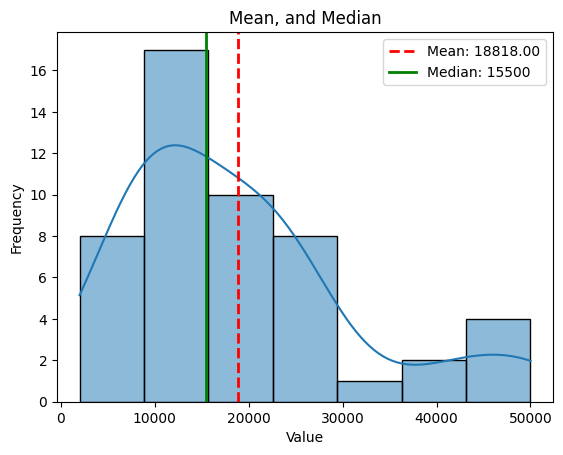

In [29]:
# Calculate mean, median, and mode
mean = income_df["Mthly_HH_Expense"].mean()
median = income_df["Mthly_HH_Expense"].median()

fig, ax = plt.subplots()
sns.histplot(income_df["Mthly_HH_Expense"], kde=True, ax=ax)

# Annotate mean, median, and mode
ax.axvline(mean, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean:.2f}')
ax.axvline(median, color='g', linestyle='-', linewidth=2, label=f'Median: {median:.0f}')

ax.legend()
ax.set_title('Mean, and Median')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.show()

#### Dispersion

In [30]:
income_df['Highest_Qualified_Member'].unique()

array([1, 0, 2, 3, 4])

In [31]:
education_mapping = {
    'Illiterate': 0,
    'Under-Graduate': 1,
    'Graduate': 2,
    'Post-Graduate': 3,
    'Professional': 4
}

income_df['Highest_Qualified_Member'] = income_df['Highest_Qualified_Member'].map(education_mapping)

In [16]:
income_df['Highest_Qualified_Member'].unique()

array([1, 0, 2, 3, 4])

In [17]:
# Variance for numeric columns
income_df.var()

,0
Mthly_HH_Income,6.811009e+08
Mthly_HH_Expense,1.461733e+08
No_of_Fly_Members,2.302449e+00
Emi_or_Rent_Amt,3.895551e+07
Annual_HH_Income,1.024869e+11
Highest_Qualified_Member,1.536327e+00
No_of_Earning_Members,5.391837e-01


In [18]:
# Standard deviation for numeric columns
income_df.std()

,0
Mthly_HH_Income,26097.908979
Mthly_HH_Expense,12090.216824
No_of_Fly_Members,1.517382
Emi_or_Rent_Amt,6241.434948
Annual_HH_Income,320135.792123
Highest_Qualified_Member,1.239486
No_of_Earning_Members,0.734291


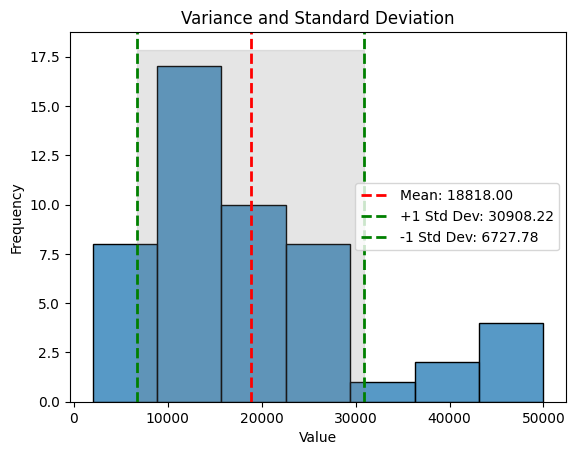

In [19]:
# Generate random data
np.random.seed(0)

# Calculate mean and standard deviation
mean = income_df["Mthly_HH_Expense"].mean()
std_dev = income_df["Mthly_HH_Expense"].std()
var = income_df["Mthly_HH_Expense"].var()

fig, ax = plt.subplots()
sns.histplot(income_df["Mthly_HH_Expense"], kde=False, ax=ax)

# Annotate mean and standard deviation
ax.axvline(mean, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean:.2f}')
ax.axvline(mean + std_dev, color='g', linestyle='--', linewidth=2, label=f'+1 Std Dev: {mean + std_dev:.2f}')
ax.axvline(mean - std_dev, color='g', linestyle='--', linewidth=2, label=f'-1 Std Dev: {mean - std_dev:.2f}')

# Shade the area within one standard deviation
ax.fill_betweenx([0, ax.get_ylim()[1]], mean - std_dev, mean + std_dev, color='gray', alpha=0.2)

ax.legend()
ax.set_title('Variance and Standard Deviation')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.show()

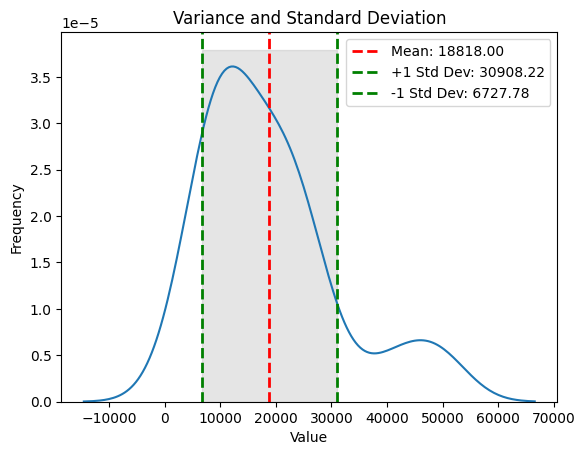

In [20]:
# Generate random data
np.random.seed(0)

# Calculate mean and standard deviation
mean = income_df["Mthly_HH_Expense"].mean()
std_dev = income_df["Mthly_HH_Expense"].std()
var = income_df["Mthly_HH_Expense"].var()

fig, ax = plt.subplots()
sns.kdeplot(income_df["Mthly_HH_Expense"], ax=ax)


# Annotate mean and standard deviation
ax.axvline(mean, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean:.2f}')
ax.axvline(mean + std_dev, color='g', linestyle='--', linewidth=2, label=f'+1 Std Dev: {mean + std_dev:.2f}')
ax.axvline(mean - std_dev, color='g', linestyle='--', linewidth=2, label=f'-1 Std Dev: {mean - std_dev:.2f}')

# Shade the area within one standard deviation
ax.fill_betweenx([0, ax.get_ylim()[1]], mean - std_dev, mean + std_dev, color='gray', alpha=0.2)

ax.legend()
ax.set_title('Variance and Standard Deviation')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.show()

### Box plot

In [21]:
# Calculate min, max, median
min_expense = income_df["Mthly_HH_Expense"].min()
max_expense = income_df["Mthly_HH_Expense"].max()
median_expense = income_df["Mthly_HH_Expense"].median()

print(f"Min Expense: {min_expense}")
print(f"Max Expense: {max_expense}")
print(f"Median Expense: {median_expense}")

Min Expense: 2000
Max Expense: 50000
Median Expense: 15500.0


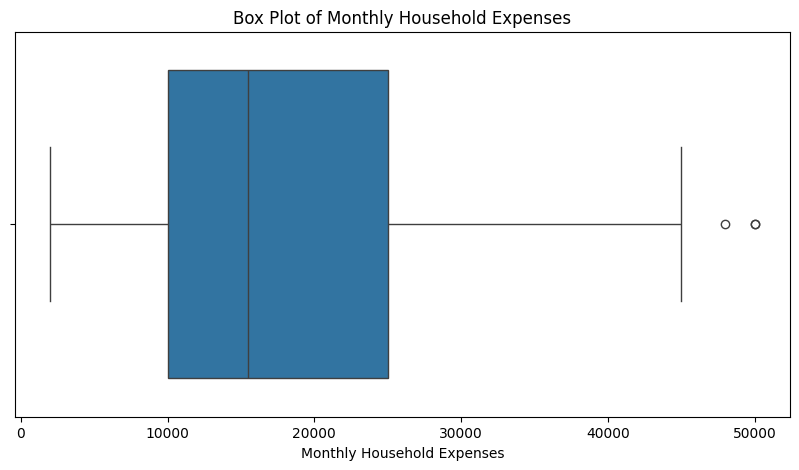

In [22]:
# Create box plot
plt.figure(figsize=(10, 5))
sns.boxplot(x="Mthly_HH_Expense", data=income_df)
plt.title("Box Plot of Monthly Household Expenses")
plt.xlabel("Monthly Household Expenses")
plt.show()

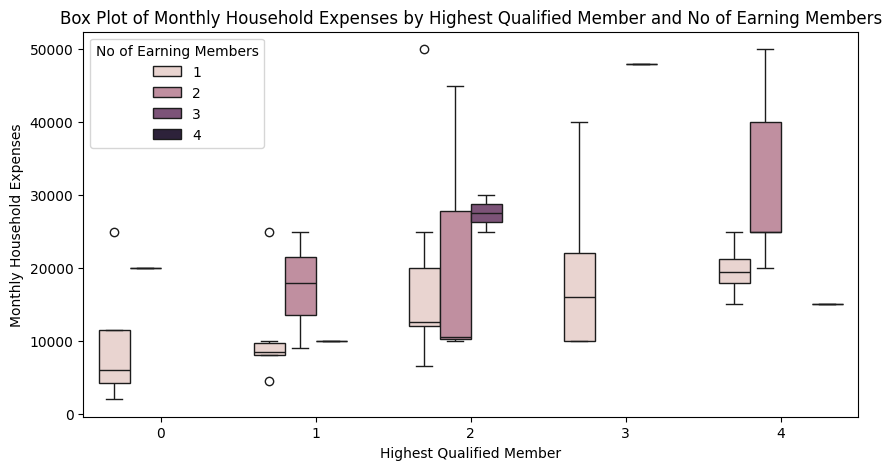

In [23]:
# Box plot with hue
plt.figure(figsize=(10, 5))
sns.boxplot(x="Highest_Qualified_Member", y="Mthly_HH_Expense", hue="No_of_Earning_Members", data=income_df)
plt.title("Box Plot of Monthly Household Expenses by Highest Qualified Member and No of Earning Members")
plt.xlabel("Highest Qualified Member")
plt.ylabel("Monthly Household Expenses")
plt.legend(title="No of Earning Members")
plt.show()

### Violin plot

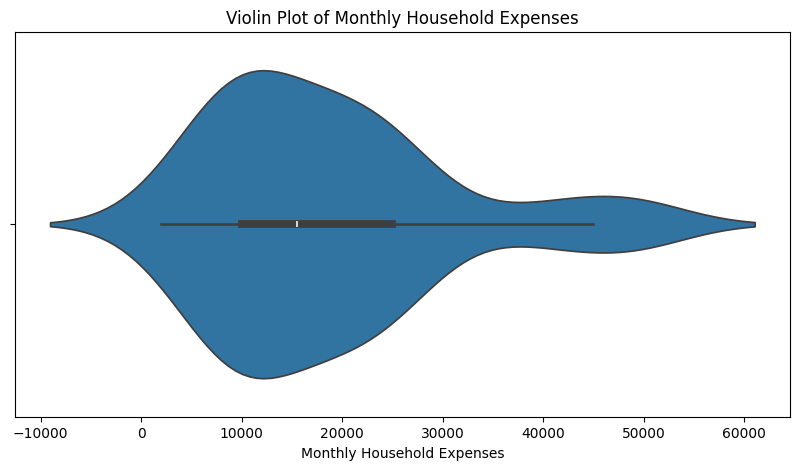

In [24]:
# Create violin plot
plt.figure(figsize=(10, 5))
sns.violinplot(x="Mthly_HH_Expense", data=income_df)
plt.title("Violin Plot of Monthly Household Expenses")
plt.xlabel("Monthly Household Expenses")
plt.show()

/tmp/ipykernel_4242/3942834228.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="No of Earning Members")


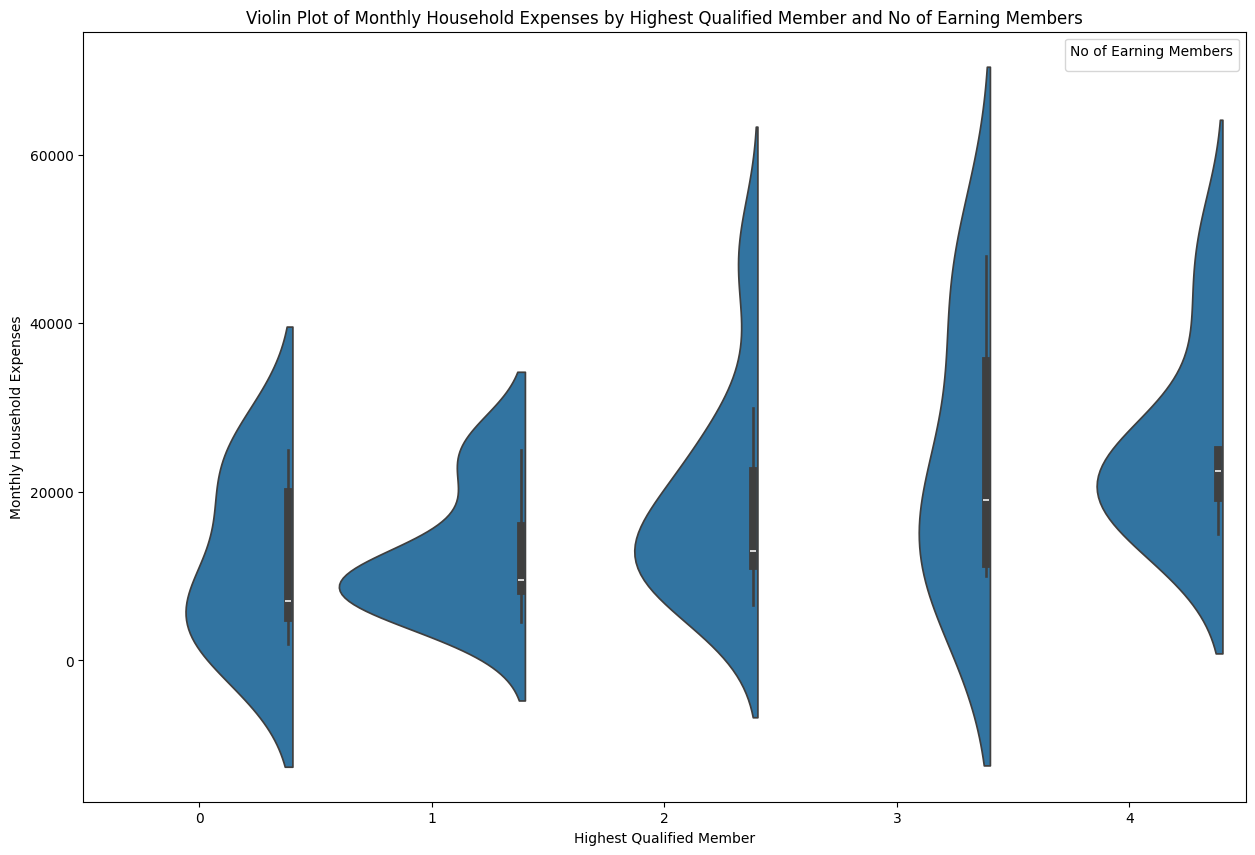

In [25]:
# Violin plot with multiple variables. You can also add hue e.g by adding hue="No_of_Earning_Members" in sns.violinplot()
plt.figure(figsize=(15, 10))
sns.violinplot(x="Highest_Qualified_Member", y="Mthly_HH_Expense", data=income_df, split=True)
plt.title("Violin Plot of Monthly Household Expenses by Highest Qualified Member and No of Earning Members")
plt.xlabel("Highest Qualified Member")
plt.ylabel("Monthly Household Expenses")
plt.legend(title="No of Earning Members")
plt.show()

# Bi-variate Analysis

### Covariance and Correlation

In [ ]:
# Generate random data
np.random.seed(0)
x = np.random.randn(1000)
y = 2.5 * x + np.random.randn(1000) * .5

# Calculate covariance matrix
cov_matrix = np.cov(x, y)
covariance = cov_matrix[0, 1]

# Calculate correlation coefficient
correlation = np.corrcoef(x, y)[0, 1]

print(f"Covariance: {covariance}")
print(f"Correlation: {correlation}")

Covariance: 2.4229543467167285
Correlation: 0.9810871686893852


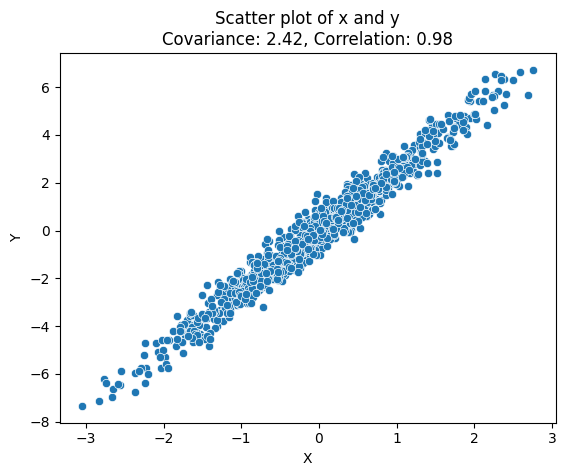

In [ ]:
# Plot data and show linear relationship
fig, ax = plt.subplots()
sns.scatterplot(x=x, y=y, ax=ax)
ax.set_title(f'Scatter plot of x and y\nCovariance: {covariance:.2f}, Correlation: {correlation:.2f}')
plt.xlabel('X')
plt.ylabel('Y')

plt.show()

Covariance: -2.4530939831739342
Correlation: -0.9815363415850888


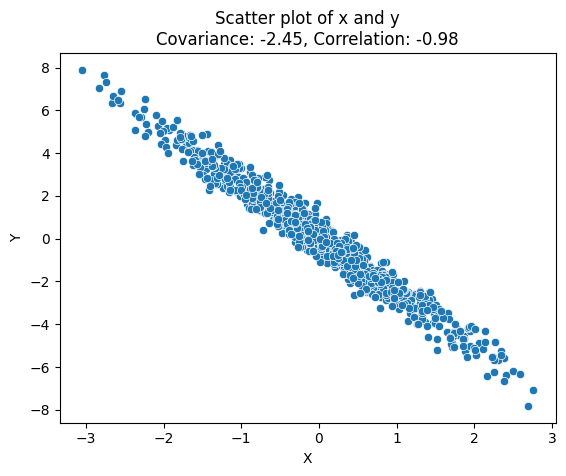

In [ ]:
# Generate random data
np.random.seed(0)
x = np.random.randn(1000)
y = -2.5 * x + np.random.randn(1000) * 0.5

# Calculate covariance matrix
cov_matrix = np.cov(x, y)
covariance = cov_matrix[0, 1]

# Calculate correlation coefficient
correlation = np.corrcoef(x, y)[0, 1]

print(f"Covariance: {covariance}")
print(f"Correlation: {correlation}")

# Plot data and show linear relationship
fig, ax = plt.subplots()
sns.scatterplot(x=x, y=y, ax=ax)
ax.set_title(f'Scatter plot of x and y\nCovariance: {covariance:.2f}, Correlation: {correlation:.2f}')
plt.xlabel('X')
plt.ylabel('Y')

plt.show()

In [ ]:
income_df.cov()

,Mthly_HH_Income,Mthly_HH_Expense,No_of_Fly_Members,Emi_or_Rent_Amt,Annual_HH_Income,Highest_Qualified_Member,No_of_Earning_Members
Mthly_HH_Income,6.811009e+08,2.048465e+08,17753.591837,6.022980e+06,8.106864e+09,12456.163265,6666.653061
Mthly_HH_Expense,2.048465e+08,1.461733e+08,11735.632653,3.058257e+07,2.288330e+09,6052.897959,2769.102041
No_of_Fly_Members,1.775359e+04,1.173563e+04,2.302449,8.126531e+02,2.093019e+05,0.441633,0.665714
Emi_or_Rent_Amt,6.022980e+06,3.058257e+07,812.653061,3.895551e+07,5.426263e+06,615.102041,-446.530612
Annual_HH_Income,8.106864e+09,2.288330e+09,209301.854694,5.426263e+06,1.024869e+11,135753.913469,69741.266939
Highest_Qualified_Member,1.245616e+04,6.052898e+03,0.441633,6.151020e+02,1.357539e+05,1.536327,0.168163
No_of_Earning_Members,6.666653e+03,2.769102e+03,0.665714,-4.465306e+02,6.974127e+04,0.168163,0.539184


In [ ]:
income_df.corr()

,Mthly_HH_Income,Mthly_HH_Expense,No_of_Fly_Members,Emi_or_Rent_Amt,Annual_HH_Income,Highest_Qualified_Member,No_of_Earning_Members
Mthly_HH_Income,1.000000,0.649215,0.448317,0.036976,0.970315,0.385067,0.347883
Mthly_HH_Expense,0.649215,1.000000,0.639702,0.405280,0.591222,0.403913,0.311915
No_of_Fly_Members,0.448317,0.639702,1.000000,0.085808,0.430868,0.234814,0.597482
Emi_or_Rent_Amt,0.036976,0.405280,0.085808,1.000000,0.002716,0.079510,-0.097431
Annual_HH_Income,0.970315,0.591222,0.430868,0.002716,1.000000,0.342118,0.296679
Highest_Qualified_Member,0.385067,0.403913,0.234814,0.079510,0.342118,1.000000,0.184766
No_of_Earning_Members,0.347883,0.311915,0.597482,-0.097431,0.296679,0.184766,1.000000


Covariance: 204846485.7142857
Correlation: 0.6492152549316462


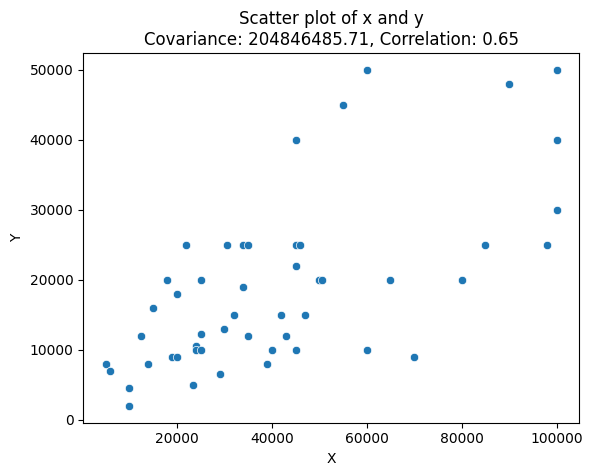

In [ ]:
# Generate random data
x = income_df['Mthly_HH_Income']
y = income_df['Mthly_HH_Expense']

# Calculate covariance matrix
cov_matrix = np.cov(x, y)
covariance = cov_matrix[0, 1]

# Calculate correlation coefficient
correlation = np.corrcoef(x, y)[0, 1]

print(f"Covariance: {covariance}")
print(f"Correlation: {correlation}")

# Plot data and show linear relationship
fig, ax = plt.subplots()
sns.scatterplot(x=x, y=y, ax=ax)
ax.set_title(f'Scatter plot of x and y\nCovariance: {covariance:.2f}, Correlation: {correlation:.2f}')
plt.xlabel('X')
plt.ylabel('Y')

plt.show()

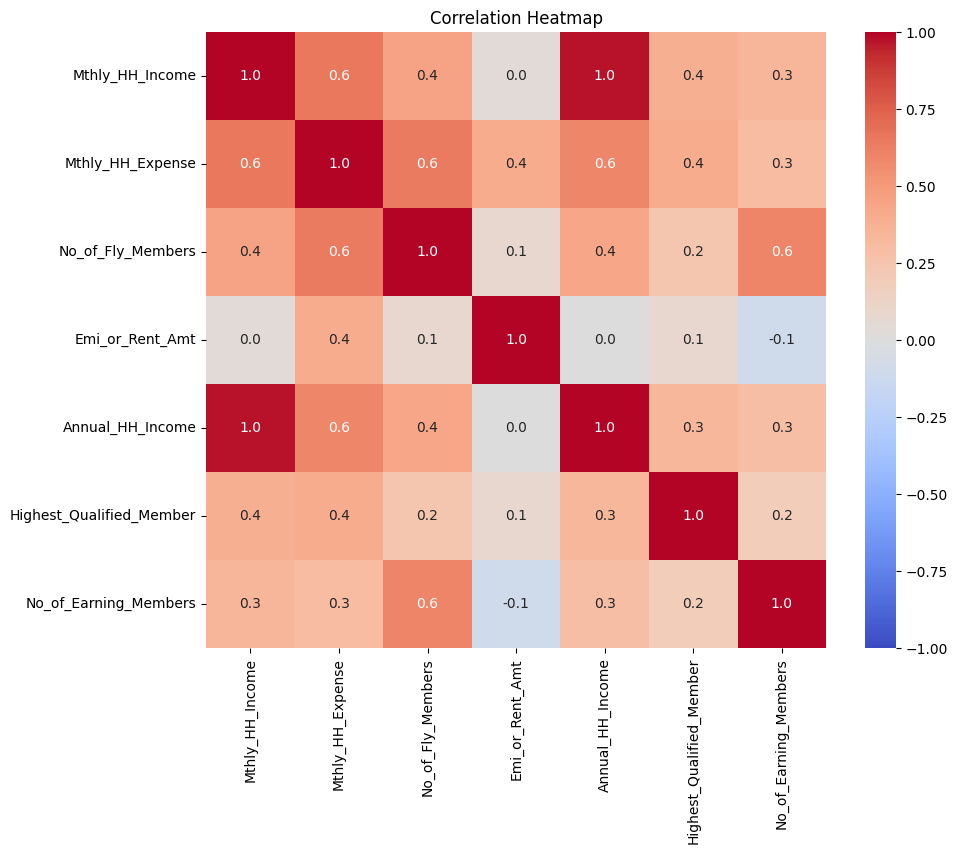

In [ ]:
# Calculate the correlation matrix
correlation_matrix = income_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.1f')
plt.title("Correlation Heatmap")
plt.show()

## Analyzing Black Friday sales

Now it's your turn to do some statical analysis on this new dataset!

In [ ]:
bf_data = pd.read_csv("https://raw.githubusercontent.com/anyoneai/notebooks/main/datasets/BlackFriday.csv")
bf_data

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969
...,...,...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,M,36-45,16,C,1,0,1,2.0,NaN,11664
537573,1004737,P00111142,M,36-45,16,C,1,0,1,15.0,16.0,19196
537574,1004737,P00345942,M,36-45,16,C,1,0,8,15.0,NaN,8043
537575,1004737,P00285842,M,36-45,16,C,1,0,5,NaN,NaN,7172
